# EDA — BGL Dataset

Exploratory Data Analysis on the BGL (Blue Gene/L supercomputer) dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

WINDOW = 60   # change to 10 or 30 to match your preprocessing
print('Libraries loaded!')

Libraries loaded!


c:\Users\shriy\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.25.2 and <2.6.0 is required for this version of SciPy (detected version 1.24.3)
  from scipy.stats import gaussian_kde


## 1. Load Data

In [3]:
train_df = pd.read_csv(f'../data/BGL/train_{WINDOW}s.csv')
test_df  = pd.read_csv(f'../data/BGL/test_{WINDOW}s.csv')
df       = pd.concat([train_df, test_df]).reset_index(drop=True)

print(f'Train : {len(train_df):,} rows')
print(f'Test  : {len(test_df):,} rows')
print(f'Total : {len(df):,} rows')
df.head(3)

Train : 18,270 rows
Test  : 6,241 rows
Total : 24,511 rows


,log_paragraph,label,num_lines,window_start
0,instruction cache parity error corrected instr...,0,224,1.117839e+09
1,instruction cache parity error corrected instr...,0,355,1.117839e+09
2,instruction cache parity error corrected instr...,0,399,1.117839e+09


## 2. Dataset Overview

In [4]:
normal_count  = len(df[df['label'] == 0])
anomaly_count = len(df[df['label'] == 1])
total         = len(df)

print('=' * 45)
print('  BGL Dataset Overview')
print('=' * 45)
print(f'  Total windows    : {total:,}')
print(f'  Normal windows   : {normal_count:,}')
print(f'  Anomaly windows  : {anomaly_count:,}')
print(f'  Anomaly ratio    : {anomaly_count/total*100:.2f}%')
print(f'  Window size      : {WINDOW}s')
print()
print('  Paper reports ~8.67% anomaly ratio in test set')

  BGL Dataset Overview
  Total windows    : 24,511
  Normal windows   : 22,838
  Anomaly windows  : 1,673
  Anomaly ratio    : 6.83%
  Window size      : 60s

  Paper reports ~8.67% anomaly ratio in test set


## 3. Class Distribution

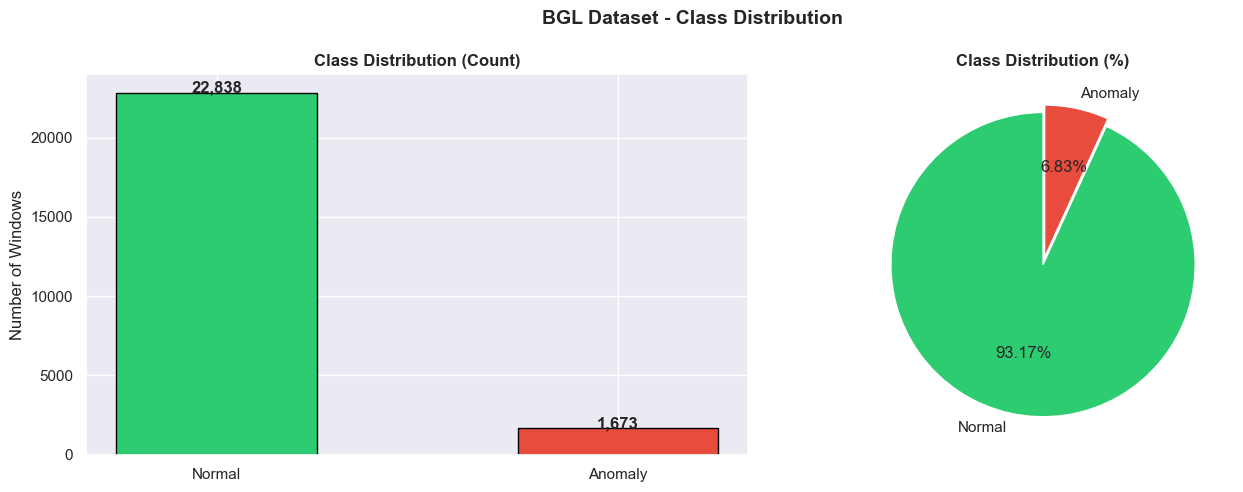

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels  = ['Normal', 'Anomaly']
counts  = [normal_count, anomaly_count]
colors  = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Windows')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('BGL Dataset - Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bgl_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Window Size Analysis
BGL uses sliding windows — let's compare different window sizes

In [6]:
# Compare stats across window sizes if you have all 3
window_stats = []
for w in [10, 30, 60]:
    try:
        tr = pd.read_csv(f'data/BGL/train_{w}s.csv')
        te = pd.read_csv(f'data/BGL/test_{w}s.csv')
        d  = pd.concat([tr, te])
        window_stats.append({
            'window': f'{w}s',
            'total' : len(d),
            'normal': len(d[d['label']==0]),
            'anomaly': len(d[d['label']==1]),
            'anomaly_ratio': len(d[d['label']==1])/len(d)*100,
            'avg_lines': d['num_lines'].mean()
        })
    except FileNotFoundError:
        print(f'  {w}s window file not found - skipping')

if window_stats:
    stats_df = pd.DataFrame(window_stats)
    print('Window Size Comparison:')
    print(stats_df.to_string(index=False))

  10s window file not found - skipping
  30s window file not found - skipping
  60s window file not found - skipping


## 5. Session Length Distribution

Lines per Window Stats:
         count    mean     std  min   25%    50%    75%      max
label                                                           
0      22838.0  184.57  665.96  1.0   2.0    4.0   35.0  16179.0
1       1673.0  297.85  445.63  1.0  29.0  224.0  401.0   4122.0


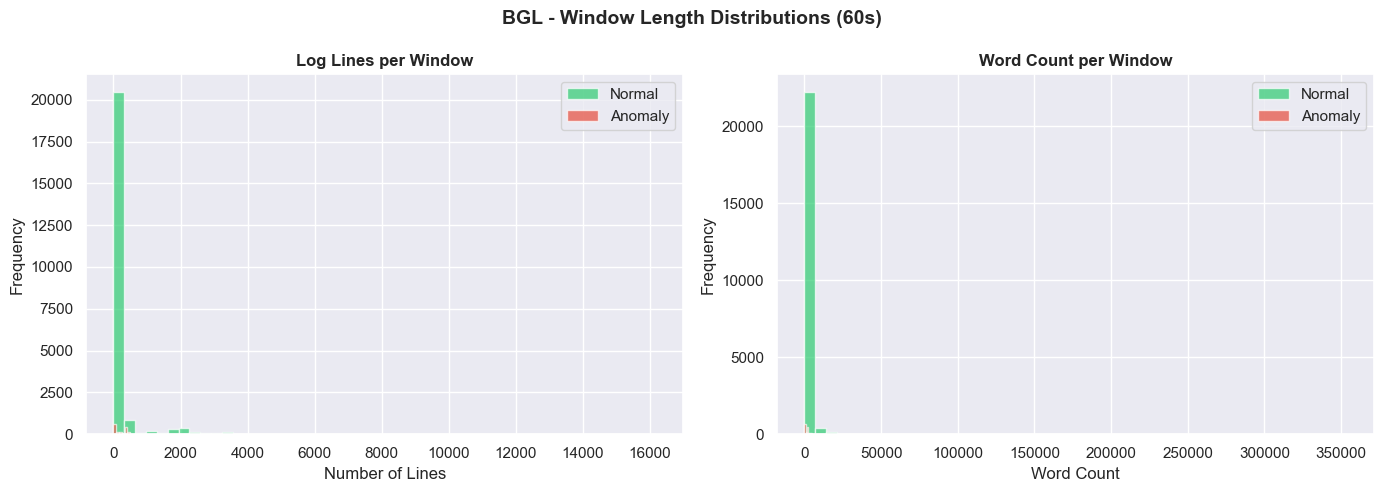

In [7]:
df['word_count'] = df['log_paragraph'].apply(lambda x: len(str(x).split()))

normal_df  = df[df['label'] == 0]
anomaly_df = df[df['label'] == 1]

print('Lines per Window Stats:')
print(df.groupby('label')['num_lines'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_df['num_lines'],  bins=50, alpha=0.7, color='#2ecc71', label='Normal')
axes[0].hist(anomaly_df['num_lines'], bins=50, alpha=0.7, color='#e74c3c', label='Anomaly')
axes[0].set_title('Log Lines per Window', fontweight='bold')
axes[0].set_xlabel('Number of Lines')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(normal_df['word_count'],  bins=50, alpha=0.7, color='#2ecc71', label='Normal')
axes[1].hist(anomaly_df['word_count'], bins=50, alpha=0.7, color='#e74c3c', label='Anomaly')
axes[1].set_title('Word Count per Window', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle(f'BGL - Window Length Distributions ({WINDOW}s)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bgl_window_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Token Length Analysis

In [8]:
from transformers import RobertaTokenizer

print('Loading RoBERTa tokenizer...')
tokenizer  = RobertaTokenizer.from_pretrained('roberta-base')
sample_df  = df.sample(min(1000, len(df)), random_state=42).copy()

print(f'Tokenizing {len(sample_df)} samples...')
sample_df['token_count'] = sample_df['log_paragraph'].apply(
    lambda x: len(tokenizer.encode(str(x), truncation=False))
)

q80 = sample_df['token_count'].quantile(0.8)
print(f'\nToken Count Stats:')
print(sample_df['token_count'].describe().round(2))
print(f'\n0.8 quantile : {q80:.0f} tokens')
print(f'Model to use : {"RoBERTa" if q80 <= 512 else "Longformer"}')

c:\Users\shriy\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading RoBERTa tokenizer...


Token indices sequence length is longer than the specified maximum sequence length for this model (3938 > 512). Running this sequence through the model will result in indexing errors


Tokenizing 1000 samples...

Token Count Stats:
count      1000.00
mean       2239.42
std        8067.03
min           5.00
25%          22.25
50%          97.00
75%        1085.75
max      184638.00
Name: token_count, dtype: float64

0.8 quantile : 1868 tokens
Model to use : Longformer


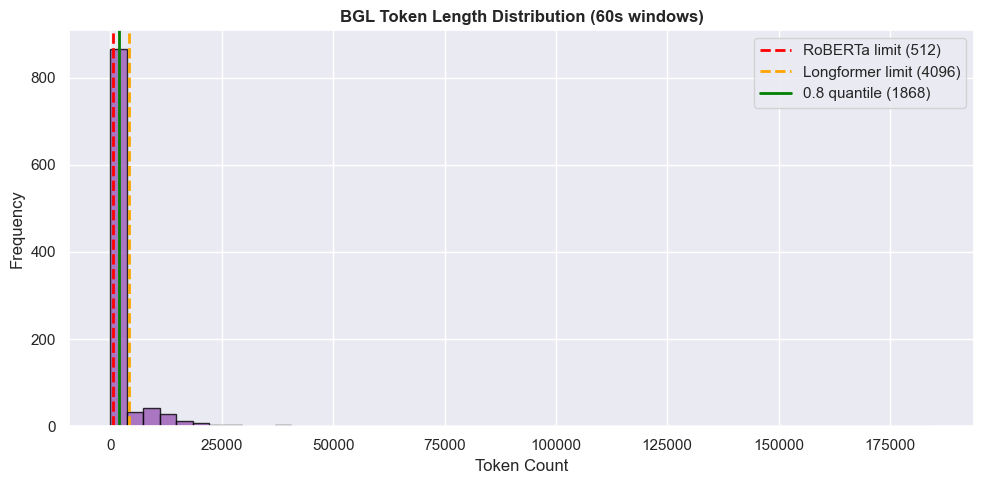

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(sample_df['token_count'], bins=50, color='#9b59b6', edgecolor='black', alpha=0.8)
ax.axvline(x=512,  color='red',    linestyle='--', lw=2, label='RoBERTa limit (512)')
ax.axvline(x=4096, color='orange', linestyle='--', lw=2, label='Longformer limit (4096)')
ax.axvline(x=q80,  color='green',  linestyle='-',  lw=2, label=f'0.8 quantile ({q80:.0f})')

ax.set_title(f'BGL Token Length Distribution ({WINDOW}s windows)', fontweight='bold')
ax.set_xlabel('Token Count')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('bgl_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Log Content Analysis

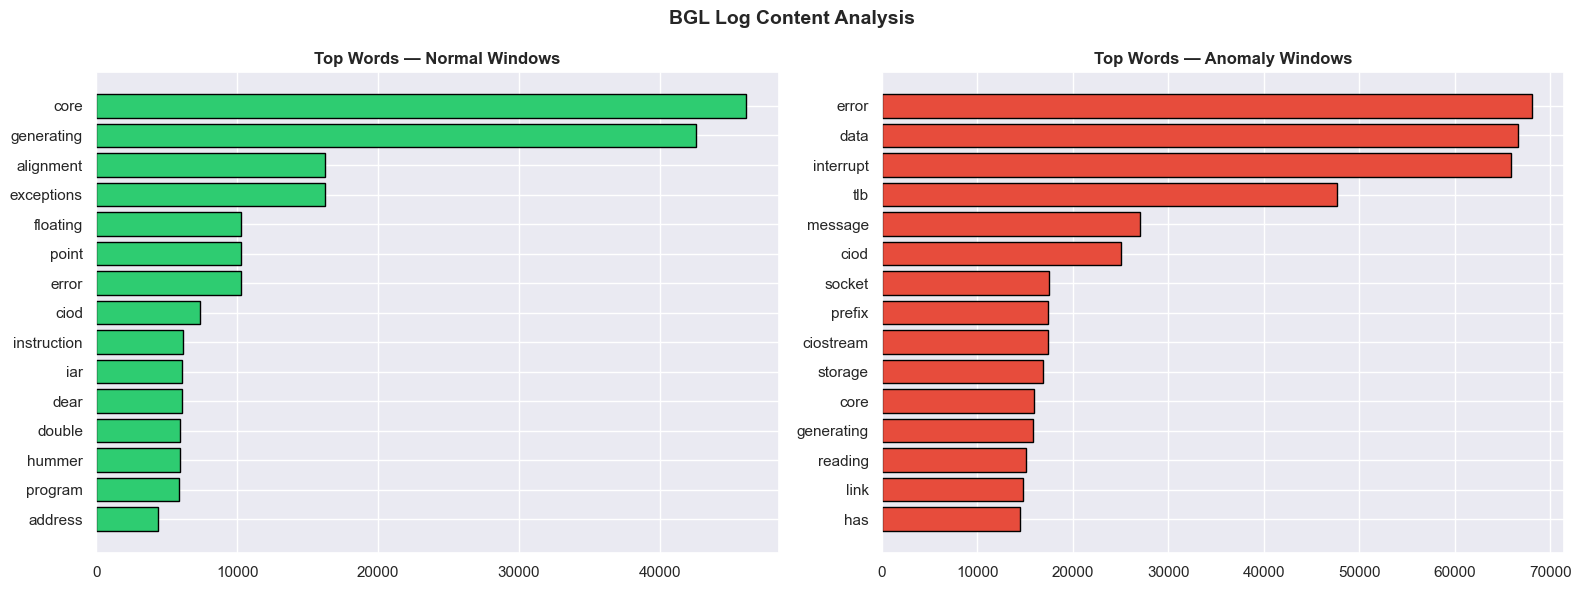

In [10]:
def get_top_words(texts, n=15):
    stopwords = {'for', 'the', 'to', 'of', 'in', 'is', 'a', 'an', 'and', 'or', 'at', 'on'}
    all_words = []
    for text in texts:
        words = re.findall(r'[a-zA-Z]+', str(text).lower())
        all_words.extend([w for w in words if w not in stopwords and len(w) > 2])
    return Counter(all_words).most_common(n)

normal_words  = get_top_words(normal_df['log_paragraph'].sample(min(500, len(normal_df))))
anomaly_words = get_top_words(anomaly_df['log_paragraph'].sample(min(500, len(anomaly_df))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_n, counts_n = zip(*normal_words)
axes[0].barh(words_n, counts_n, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words — Normal Windows', fontweight='bold')
axes[0].invert_yaxis()

words_a, counts_a = zip(*anomaly_words)
axes[1].barh(words_a, counts_a, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words — Anomaly Windows', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('BGL Log Content Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bgl_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Train/Test Split Verification

In [11]:
print('Train Set:')
print(f'  Total   : {len(train_df):,}')
print(f'  Normal  : {len(train_df[train_df["label"]==0]):,}')
print(f'  Anomaly : {len(train_df[train_df["label"]==1]):,} (should be 0!)')

print('\nTest Set:')
test_anom = len(test_df[test_df['label']==1])
print(f'  Total         : {len(test_df):,}')
print(f'  Normal        : {len(test_df[test_df["label"]==0]):,}')
print(f'  Anomaly       : {test_anom:,}')
print(f'  Anomaly ratio : {test_anom/len(test_df)*100:.2f}%')
print(f'  Paper reports : ~8.67%')

Train Set:
  Total   : 18,270
  Normal  : 18,270
  Anomaly : 0 (should be 0!)

Test Set:
  Total         : 6,241
  Normal        : 4,568
  Anomaly       : 1,673
  Anomaly ratio : 26.81%
  Paper reports : ~8.67%


## 9. Summary

In [12]:
print('=' * 55)
print('  BGL EDA Summary')
print('=' * 55)
print(f'  Total windows       : {total:,}')
print(f'  Anomaly ratio       : {anomaly_count/total*100:.2f}%')
print(f'  Avg lines/window    : {df["num_lines"].mean():.1f}')
print(f'  Avg words/window    : {df["word_count"].mean():.1f}')
print(f'  0.8 quantile tokens : {q80:.0f}')
print(f'  Model to use        : {"RoBERTa" if q80 <= 512 else "Longformer"}')
print(f'  Window size used    : {WINDOW}s')
print('=' * 55)

  BGL EDA Summary
  Total windows       : 24,511
  Anomaly ratio       : 6.83%
  Avg lines/window    : 192.3
  Avg words/window    : 1195.4
  0.8 quantile tokens : 1868
  Model to use        : Longformer
  Window size used    : 60s
